<a href="https://colab.research.google.com/github/zorGizem/Erken-Evre-Alzhemir-Tespiti/blob/main/notebooks/kod/Perplane_dropout%3D0_65.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import nibabel as nib
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print(f"PyTorch: {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Cihaz  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Seed   : {SEED}")

PyTorch: 2.11.0+cu128
Cihaz  : cuda
GPU    : NVIDIA A100-SXM4-40GB
Seed   : 42


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import shutil, os

drive_path = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Slice_v2/'
zip_cn   = drive_path + 'Slice_CN.zip'
zip_emci = drive_path + 'Slice_EMCI.zip'

local_dir = '/content/dataset'
os.makedirs(local_dir, exist_ok=True)

if not os.path.exists(os.path.join(local_dir, 'Slice_CN')):
    print("Slice_CN aciliyor...")
    shutil.unpack_archive(zip_cn, local_dir)
    print("  Tamamlandi.")
else:
    print("Slice_CN zaten var.")

if not os.path.exists(os.path.join(local_dir, 'Slice_EMCI')):
    print("Slice_EMCI aciliyor...")
    shutil.unpack_archive(zip_emci, local_dir)
    print("  Tamamlandi.")
else:
    print("Slice_EMCI zaten var.")

print("Veri hazir.")

Slice_CN aciliyor...
  Tamamlandi.
Slice_EMCI aciliyor...
  Tamamlandi.
Veri hazir.


In [ ]:
import zipfile, os

# Test zip'lerinin Drive'daki yeri
test_zip_cn   = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_CN.zip'
test_zip_emci = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI.zip'

# Yerele acilacak hedef
os.makedirs('/content/dataset_test', exist_ok=True)

for zip_yolu in [test_zip_cn, test_zip_emci]:
    with zipfile.ZipFile(zip_yolu, 'r') as z:
        z.extractall('/content/dataset_test')
    print(f"Acildi: {zip_yolu}")

# Ne cikti, kontrol et
print("\nIcerik:")
for d in sorted(os.listdir('/content/dataset_test')):
    print("  ", d)

Acildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_CN.zip
Acildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI.zip

Icerik:
   Slice_CN
   Slice_EMCI


In [ ]:
import datetime, os

zaman_damgasi = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")
deney_adi = f"DenseNet_PerPlane_Ensemble_YOL2_{zaman_damgasi}"
ANA_KLASOR = f'/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/{deney_adi}'

os.makedirs(ANA_KLASOR, exist_ok=True)
print(f"Ana klasor: {ANA_KLASOR}")

CONFIG = {
    # --- EGITIM verisi (train + validation) ---
    "kaynak_CN"     : '/content/dataset/Slice_CN',
    "kaynak_EMCI"   : '/content/dataset/Slice_EMCI',

    # --- IZOLE TEST verisi (egitime HIC girmez) ---
    "kaynak_CN_test"   : '/content/dataset_test/Slice_CN',
    "kaynak_EMCI_test" : '/content/dataset_test/Slice_EMCI',

    "ana_klasor"    : ANA_KLASOR,

    "k_fold"        : 5,
    "batch_size"    : 16,
    "epoch"         : 80,

    # --- OVERFIT DUZELTMELERI (degisen degerler) ---
    "lr_finetune"   : 2e-4,    # 5e-4 -> 2e-4  (backbone yavaslatildi)
    "lr_head"       : 1e-3,    # 5e-3 -> 1e-3  (kafa cok hizliydi, dustur)
    "dropout"       : 0.65,     # 0.5 -> 0.6
    "weight_decay"  : 5e-4,    # 1e-4 -> 5e-4  (en etkili overfit kaldiraci)
    "patience"      : 12,      # 15 -> 12

    "img_size"      : 224,
    "slice_per_plane": 10,
    "val_orani"     : 0.15,
    "num_workers"   : 8,
    "min_lr"        : 1e-6,

    "use_class_weights" : True,
    "label_smoothing"   : 0.1,
    "grad_clip_norm"    : 1.0,
}

print(f"Batch size    : {CONFIG['batch_size']}")
print(f"Train/Val     : %{int((1-CONFIG['val_orani'])*100)} / %{int(CONFIG['val_orani']*100)}")
print(f"LR finetune   : {CONFIG['lr_finetune']}  (dusuruldu)")
print(f"LR head       : {CONFIG['lr_head']}  (dusuruldu)")
print(f"Dropout       : {CONFIG['dropout']}  |  Weight Decay: {CONFIG['weight_decay']}")
print(f"Patience      : {CONFIG['patience']}")
print("\nNOT: Test klasor yollarini (kaynak_CN_test / kaynak_EMCI_test) kendin guncelle.")

Ana klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58
Batch size    : 16
Train/Val     : %85 / %15
LR finetune   : 0.0002  (dusuruldu)
LR head       : 0.001  (dusuruldu)
Dropout       : 0.65  |  Weight Decay: 0.0005
Patience      : 12

NOT: Test klasor yollarini (kaynak_CN_test / kaynak_EMCI_test) kendin guncelle.


In [ ]:
def dosya_dan_duzlem_cikar(dosya_adi):
    ad_lower = dosya_adi.lower()
    if 'sagital' in ad_lower or 'sagittal' in ad_lower:
        return 'sagital'
    elif 'aksiyal' in ad_lower or 'axial' in ad_lower:
        return 'aksiyal'
    elif 'koronal' in ad_lower or 'coronal' in ad_lower:
        return 'koronal'
    return None


def veri_listesi_olustur(config):
    veriler = []
    for sinif, kaynak in [(0, config["kaynak_CN"]), (1, config["kaynak_EMCI"])]:
        if not os.path.exists(kaynak):
            print(f"Klasor bulunamadi: {kaynak}")
            continue
        for hasta_id in sorted(os.listdir(kaynak)):
            hasta_yol = os.path.join(kaynak, hasta_id)
            if not os.path.isdir(hasta_yol):
                continue
            for seans_id in sorted(os.listdir(hasta_yol)):
                seans_yol = os.path.join(hasta_yol, seans_id)
                if not os.path.isdir(seans_yol):
                    continue
                seans_dict = {
                    'hasta_id': hasta_id, 'seans_id': seans_id,
                    'etiket': sinif,
                    'sagital': [], 'aksiyal': [], 'koronal': []
                }
                for f in sorted(os.listdir(seans_yol)):
                    if f.endswith('.nii.gz') or f.endswith('.nii'):
                        duzlem = dosya_dan_duzlem_cikar(f)
                        if duzlem:
                            seans_dict[duzlem].append(os.path.join(seans_yol, f))
                if (len(seans_dict['sagital']) == config["slice_per_plane"] and
                    len(seans_dict['aksiyal']) == config["slice_per_plane"] and
                    len(seans_dict['koronal']) == config["slice_per_plane"]):
                    veriler.append(seans_dict)
    return veriler


tum_veriler = veri_listesi_olustur(CONFIG)
n_cn   = sum(1 for x in tum_veriler if x['etiket'] == 0)
n_emci = sum(1 for x in tum_veriler if x['etiket'] == 1)
print(f"Toplam seans : {len(tum_veriler)}")
print(f"  CN seans   : {n_cn}")
print(f"  EMCI seans : {n_emci}")
print(f"  Hasta sayisi: {len(set(x['hasta_id'] for x in tum_veriler))}")

Toplam seans : 1990
  CN seans   : 1043
  EMCI seans : 947
  Hasta sayisi: 466


In [ ]:
class SinglePlaneDataset(Dataset):
    """
    Tek bir duzlem icin Dataset.

    duzlem parametresi: 'sagital', 'aksiyal' veya 'koronal'
    Her __getitem__ sadece o duzlemin slice'larini dondurur.

    Pipeline (Defter 1 ile ayni):
      nibabel yukle → 3 kanala genislet → ToTensor + Resize → ImageNet normalize
    """

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    def __init__(self, seans_listesi, duzlem, img_size=224):
        assert duzlem in ('sagital', 'aksiyal', 'koronal'),             f"Gecersiz duzlem: {duzlem}"
        self.seans_listesi = seans_listesi
        self.duzlem = duzlem
        self.img_size = img_size

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size), antialias=True),
            transforms.Normalize(mean=self.IMAGENET_MEAN, std=self.IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.seans_listesi)

    def _slice_yukle(self, yol):
        img = nib.load(yol).get_fdata().astype(np.float32).squeeze()
        img = np.stack([img]*3, axis=-1)
        return self.transform(img)

    def __getitem__(self, idx):
        seans = self.seans_listesi[idx]
        seans_id = f"{seans['hasta_id']}_{seans['seans_id']}"
        slices  = torch.stack([self._slice_yukle(y) for y in seans[self.duzlem]])
        etiket  = torch.tensor(seans['etiket'], dtype=torch.long)
        return seans_id, slices, etiket


def loader_olustur(seans_listesi, duzlem, config, shuffle=True):
    """Tek duzlem icin DataLoader olustur."""
    dataset = SinglePlaneDataset(seans_listesi, duzlem, img_size=config['img_size'])
    return DataLoader(
        dataset,
        batch_size=config['batch_size'],
        shuffle=shuffle,
        num_workers=config['num_workers'],
        pin_memory=True,
        worker_init_fn=seed_worker if shuffle else None,
        generator=g if shuffle else None
    )

print("SinglePlaneDataset hazir (ImageNet normalize).")
print("  Kullanim: SinglePlaneDataset(seans_listesi, 'sagital')")

SinglePlaneDataset hazir (ImageNet normalize).
  Kullanim: SinglePlaneDataset(seans_listesi, 'sagital')


In [ ]:
class SinglePlaneModel(nn.Module):
    """
    Tek duzlem modeli — DenseNet121.

    Akis:
      10 slice → DenseNet → 10 feature → Mean Pooling → 1 vektor (1024)
              → Classifier → 2 sinif (CN veya EMCI)

    Defter 1'den farki:
      - Sadece 1 backbone (3 degil)
      - Fusion yok, concat yok
      - Her duzlem bu modelin bir kopyasini alir ve bagımsiz egitilir
    """
    def __init__(self, dropout_rate=0.5, hidden_dim=256):
        super().__init__()

        # DenseNet backbone (Defter 1 ile ayni freeze stratejisi)
        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        for param in backbone.parameters():
            param.requires_grad = False
        for param in backbone.features.denseblock4.parameters():
            param.requires_grad = True
        for param in backbone.features.norm5.parameters():
            param.requires_grad = True
        backbone.classifier = nn.Identity()
        self.backbone = backbone

        feature_dim = 1024
        self.feat_dim = feature_dim

        # Siniflandirici
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, slices):
        """
        slices: (B, S, C, H, W)  — B:batch, S:10 slice, C:3, H:224, W:224
        return: (B, 2)            — CN/EMCI logits
        """
        B, S, C, H, W = slices.shape
        slices_flat = slices.view(B * S, C, H, W)          # (B*S, C, H, W)
        features_flat = self.backbone(slices_flat)          # (B*S, 1024)
        features = features_flat.view(B, S, -1)            # (B, S, 1024)
        pooled   = features.mean(dim=1)                    # (B, 1024) — mean pool
        logits   = self.classifier(pooled)                 # (B, 2)
        return logits


def model_olustur(dropout_rate=0.5, hidden_dim=256, duzlem_adi='?'):
    model = SinglePlaneModel(dropout_rate=dropout_rate, hidden_dim=hidden_dim)
    total    = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{duzlem_adi}] Toplam param   : {total:,}")
    print(f"[{duzlem_adi}] Egitilen param : {trainable:,} ({100*trainable/total:.2f}%)")
    print(f"[{duzlem_adi}] Dropout        : {dropout_rate}")
    return model.to(DEVICE)

# Test
print("Model olusturuluyor (test)...")
_t = model_olustur(0.5, 256, 'TEST')
del _t; torch.cuda.empty_cache()
print("SinglePlaneModel hazir.")

Model olusturuluyor (test)...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 175MB/s]


[TEST] Toplam param   : 7,216,770
[TEST] Egitilen param : 2,423,042 (33.58%)
[TEST] Dropout        : 0.5
SinglePlaneModel hazir.


In [ ]:
def degerlendir(model, loader, kayip_fn=None):
    """Tek duzlem modeli icin degerlendirme."""
    model.eval()
    y_true, y_pred, probs_list = [], [], []
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():
        for _, slices, lbls in loader:
            slices = slices.to(DEVICE)
            lbls   = lbls.to(DEVICE)
            logits = model(slices)
            if kayip_fn is not None:
                total_loss += kayip_fn(logits, lbls).item()
                n_batches += 1
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            y_true.extend(lbls.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            probs_list.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / n_batches if n_batches > 0 else 0.0
    return y_true, y_pred, avg_loss, probs_list

print("Degerlendirme fonksiyonu hazir.")

Degerlendirme fonksiyonu hazir.


In [ ]:
from sklearn.metrics import f1_score

class EarlyStopping:
    """Macro-F1 takip eder (iki sinifi da esit onemser).

    val_loss yerine macro-F1'e bakar; boylece bir sinifi (ornegin CN)
    ihmal eden 'her seye EMCI de' tarzi modeller kaydedilmez.
    Geri uyumluluk icin val_loss da saklanir ama karar macro-F1 ile verilir.
    """
    def __init__(self, patience=12, path='best.pth'):
        self.patience    = patience
        self.path        = path
        self.counter     = 0
        self.best_score  = -1.0      # macro-F1 (yuksek = iyi)
        self.best_loss   = float('inf')
        self.best_acc    = -1.0
        self.early_stop  = False

    def __call__(self, macro_f1, val_loss, val_acc, model):
        if macro_f1 > self.best_score:
            self.best_score = macro_f1
            self.best_loss  = val_loss
            self.best_acc   = val_acc
            torch.save(model.state_dict(), self.path)
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            return False

print("EarlyStopping hazir (MACRO-F1 based).")

EarlyStopping hazir (MACRO-F1 based).


In [ ]:
def duzlem_egit(veriler, duzlem, config, kayit_klasoru):
    """
    Tek bir duzlem icin 5-fold egitim — SADECE train/val.

    >>> Test seti bu fonksiyona HIC girmez. <<<
    Test seti disarida, izole tutulur ve yalniz en son hucrede
    birlesik ensemble uzerinden degerlendirilir.

    Her fold:
      - Hastalar bazinda %85 train / %15 val (her fold farkli random_state,
        boylece 5 farkli model -> ensemble uyeleri).
      - Model secimi val_loss uzerinden (EarlyStopping).
      - Fold sonunda en iyi model VALIDATION uzerinde raporlanir
        (accuracy, precision, recall, F1, per-class F1).
      - Model .pth olarak kaydedilir: '{duzlem}_fold_{fold}.pth'

    Dondurur:
      fold_results: her fold icin VALIDATION metrikleri
    """
    os.makedirs(kayit_klasoru, exist_ok=True)
    print(f"\n{'='*70}")
    print(f"DUZLEM: {duzlem.upper()}")
    print(f"Klasor: {kayit_klasoru}")
    print(f"{'='*70}")

    unique_pats = sorted(set(x['hasta_id'] for x in veriler))
    fold_results = []
    csv_yolu = os.path.join(kayit_klasoru, 'deney_sonuclari.csv')

    for fold in range(1, config['k_fold'] + 1):
        # Hastalar bazinda %85 train / %15 val (fold'a gore degisen seed)
        tr_ids, val_ids = train_test_split(
            unique_pats, test_size=config['val_orani'],
            random_state=SEED + fold
        )

        tr_seans  = [x for x in veriler if x['hasta_id'] in set(tr_ids)]
        val_seans = [x for x in veriler if x['hasta_id'] in set(val_ids)]

        print(f"\n{'='*70}\nFOLD {fold} [{duzlem.upper()}]")
        print(f"  Train: {len(tr_ids)} hasta / {len(tr_seans)} seans")
        print(f"  Val  : {len(val_ids)} hasta / {len(val_seans)} seans")

        for set_adi, set_data in [('Train', tr_seans), ('Val', val_seans)]:
            n_cn   = sum(1 for x in set_data if x['etiket'] == 0)
            n_emci = sum(1 for x in set_data if x['etiket'] == 1)
            t = n_cn + n_emci
            print(f"  {set_adi}: CN={n_cn} ({100*n_cn/t:.1f}%) | EMCI={n_emci} ({100*n_emci/t:.1f}%)")
        print(f"{'='*70}")

        # Class weights (train dagilimina gore)
        if config['use_class_weights']:
            n_cn_tr   = sum(1 for x in tr_seans if x['etiket'] == 0)
            n_emci_tr = sum(1 for x in tr_seans if x['etiket'] == 1)
            n_total   = n_cn_tr + n_emci_tr
            w_cn   = n_total / (2 * n_cn_tr)
            w_emci = n_total / (2 * n_emci_tr)
            class_weights = torch.tensor([w_cn, w_emci], dtype=torch.float).to(DEVICE)
            print(f"Class Weights: CN={w_cn:.3f}, EMCI={w_emci:.3f}")
        else:
            class_weights = None

        # DataLoader'lar (SADECE train + val)
        train_loader = loader_olustur(tr_seans,  duzlem, config, shuffle=True)
        val_loader   = loader_olustur(val_seans, duzlem, config, shuffle=False)

        # Model
        model = model_olustur(
            dropout_rate=config['dropout'],
            hidden_dim=256,
            duzlem_adi=duzlem.upper()
        )

        # Optimizer (backbone + head ayri LR)
        backbone_params, head_params = [], []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if 'backbone' in name:
                backbone_params.append(param)
            else:
                head_params.append(param)

        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': config['lr_finetune'],
             'weight_decay': config['weight_decay']},
            {'params': head_params,     'lr': config['lr_head'],
             'weight_decay': config['weight_decay']}
        ])

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config['epoch'], eta_min=config['min_lr']
        )

        crit = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=config['label_smoothing']
        )

        m_path = os.path.join(kayit_klasoru, f'{duzlem}_fold_{fold}.pth')
        es = EarlyStopping(patience=config['patience'], path=m_path)

        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        for epoch in range(1, config['epoch'] + 1):
            model.train()
            tr_loss, tr_correct, tr_total = 0.0, 0, 0

            for _, slices, lbls in train_loader:
                slices = slices.to(DEVICE)
                lbls   = lbls.to(DEVICE)
                optimizer.zero_grad()
                logits = model(slices)
                loss   = crit(logits, lbls)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=config['grad_clip_norm']
                )
                optimizer.step()

                tr_loss    += loss.item()
                tr_correct += (logits.argmax(1) == lbls).sum().item()
                tr_total   += lbls.size(0)

            train_loss = tr_loss / len(train_loader)
            train_acc  = tr_correct / tr_total

            y_v_t, y_v_p, val_loss, _ = degerlendir(model, val_loader, kayip_fn=crit)
            val_acc = accuracy_score(y_v_t, y_v_p)
            val_macro_f1 = f1_score(y_v_t, y_v_p, average='macro', zero_division=0)

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            improved = es(val_macro_f1, val_loss, val_acc, model)
            mark = "*" if improved else " "
            lr_bb = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:02d} {mark} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
                  f"Val mF1: {val_macro_f1:.4f} | "
                  f"LR_bb: {lr_bb:.2e}")

            if epoch in [1, 5, 10, 15]:
                n_cn_v = sum(1 for p in y_v_p if p == 0)
                n_em_v = sum(1 for p in y_v_p if p == 1)
                print(f"         Val tahmin: CN={n_cn_v}, EMCI={n_em_v}")

            if es.early_stop:
                print(f"  Sabir tukendi, Fold {fold} durduruldu (epoch {epoch}).")
                break
            scheduler.step()

        # Grafik (KORUNDU)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ep_range = range(1, len(history['train_loss']) + 1)
        axes[0].plot(ep_range, history['train_loss'], 'b-', label='Train Loss', lw=2)
        axes[0].plot(ep_range, history['val_loss'],   'r-', label='Val Loss',   lw=2)
        axes[0].set_title(f'Fold {fold} [{duzlem.upper()}] Loss')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(ep_range, history['train_acc'], 'b-', label='Train Acc', lw=2)
        axes[1].plot(ep_range, history['val_acc'],   'r-', label='Val Acc',   lw=2)
        axes[1].set_title(f'Fold {fold} [{duzlem.upper()}] Accuracy')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
        axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim([0,1])

        plt.tight_layout()
        plt.savefig(os.path.join(kayit_klasoru, f'fold_{fold}_grafik.png'),
                    dpi=100, bbox_inches='tight')
        plt.show()

        pd.DataFrame(history).to_csv(
            os.path.join(kayit_klasoru, f'fold_{fold}_metrik.csv'), index=False
        )

        # === En iyi modeli yukle ve VALIDATION uzerinde degerlendir ===
        # (Confusion matrix fold icinde KALDIRILDI; sadece metrikler)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        y_t, y_p, _, _ = degerlendir(model, val_loader)

        p, r, f, _ = precision_recall_fscore_support(y_t, y_p, average='weighted', zero_division=0)
        val_acc_best = accuracy_score(y_t, y_p)
        p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(
            y_t, y_p, average=None, labels=[0, 1], zero_division=0
        )

        print(f"\nFOLD {fold} VALIDATION SONUCLARI [{duzlem.upper()}]")
        print(f"  Val Accuracy  : {val_acc_best:.4f}")
        print(f"  Precision     : {p:.4f}")
        print(f"  Recall        : {r:.4f}")
        print(f"  F1 Score      : {f:.4f}")
        print(f"  Per-Class F1  : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f} | "
              f"Fark={abs(f_pc[0]-f_pc[1]):.4f} "
              f"{'KONTROL ET' if abs(f_pc[0]-f_pc[1]) > 0.10 else 'Normal'}")
        print(f"  Best Val Loss : {es.best_loss:.4f}")
        print(f"  Model kaydi   : {m_path}")

        fold_skoru = {
            'fold': fold,
            'val_acc'  : val_acc_best,
            'val_prec' : p, 'val_rec': r, 'val_f1': f,
            'val_f1_cn': f_pc[0], 'val_f1_emci': f_pc[1],
            'best_val_loss': es.best_loss,
            'duzlem'       : duzlem,
            'durduran_epoch': len(history['train_loss'])
        }
        fold_results.append(fold_skoru)
        pd.DataFrame(fold_results).to_csv(csv_yolu, index=False)

        del model
        torch.cuda.empty_cache()

    return fold_results

print("Egitim fonksiyonu hazir (SADECE train/val; test izole).")

Egitim fonksiyonu hazir (SADECE train/val; test izole).


EGITIM 1/3: SAGITAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital


DUZLEM: SAGITAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital

FOLD 1 [SAGITAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6532 | Train Acc: 0.6420 | Val Loss: 0.6293 | Val Acc: 0.6678 | Val mF1: 0.6389 | LR_bb: 2.00e-04
         Val tahmin: CN=65, EMCI=221
  Epoch 02   | Train Loss: 0.4571 | Train Acc: 0.8410 | Val Loss: 0.7296 | Val Acc: 0.6329 | Val mF1: 0.6154 | LR_bb: 2.00e-04
  Epoch 03   | Train Loss: 0.3272 | Train Acc: 0.9384 | Val Loss: 0.8463 | Val Acc

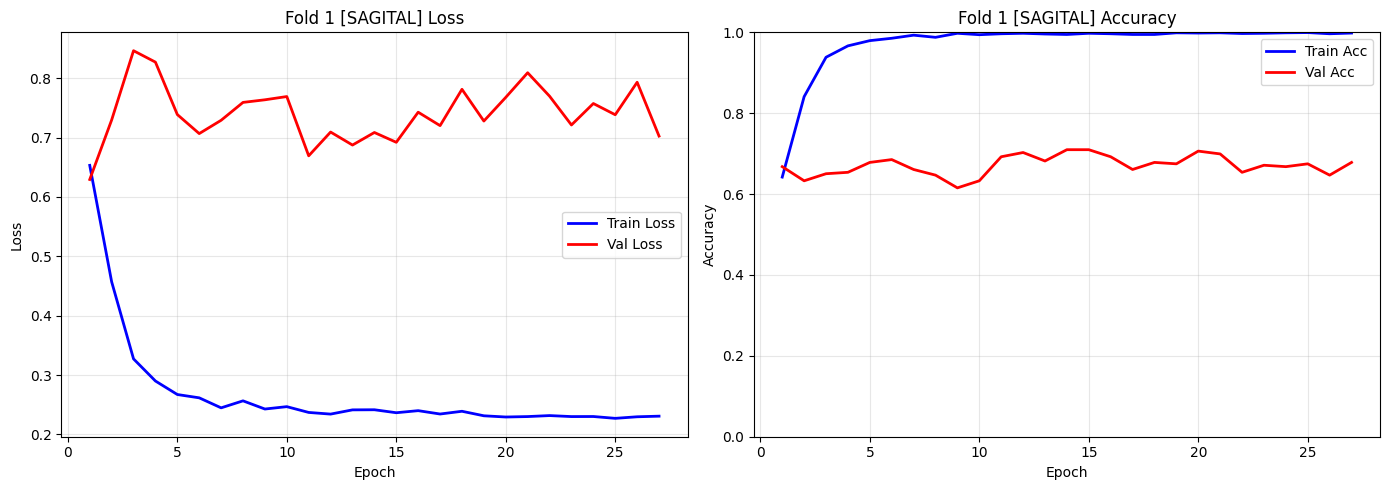


FOLD 1 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7098
  Precision     : 0.7144
  Recall        : 0.7098
  F1 Score      : 0.7074
  Per-Class F1  : CN=0.6770 | EMCI=0.7365 | Fark=0.0595 Normal
  Best Val Loss : 0.6920
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital/sagital_fold_1.pth

FOLD 2 [SAGITAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6576 | Train Acc: 0.6390 | Val Loss: 0.6419 | Val Acc: 0.6403 | Val mF1: 0.6384 | LR_bb: 2.00e-04
         Val tahmin: CN=136, EMCI=142
  Epoch 02   | Train Loss: 0.4749 | Train Acc: 0.8318 | Val Loss: 0.9601 | Val Acc: 0.5504 | Val mF1: 0.5499 | LR_bb: 2.00e-04


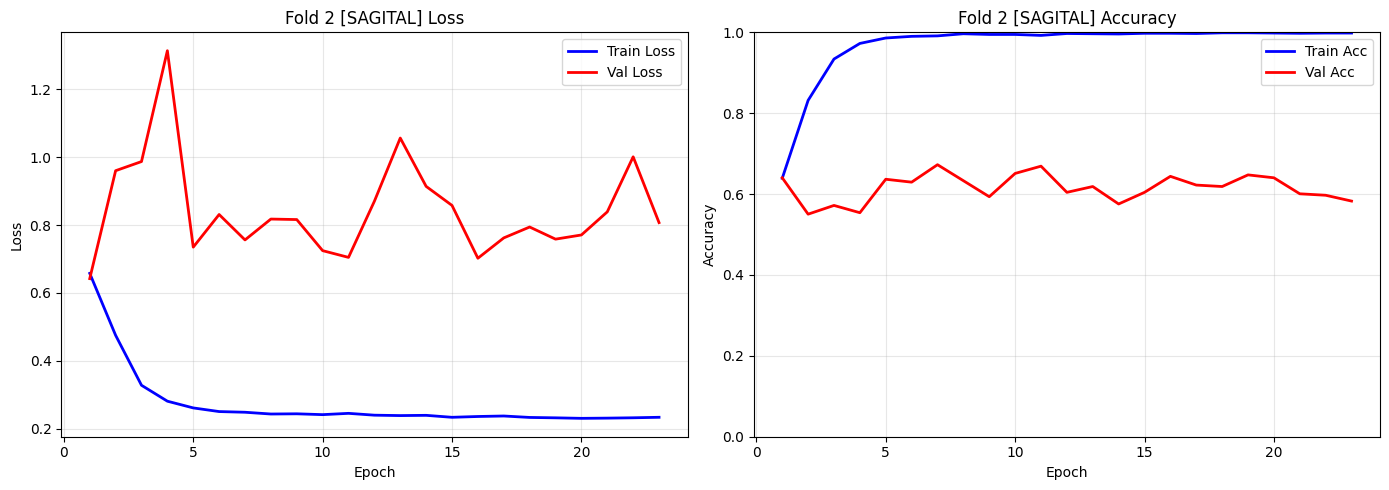


FOLD 2 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6691
  Precision     : 0.6718
  Recall        : 0.6691
  F1 Score      : 0.6701
  Per-Class F1  : CN=0.7107 | EMCI=0.6134 | Fark=0.0972 Normal
  Best Val Loss : 0.7046
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital/sagital_fold_2.pth

FOLD 3 [SAGITAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6435 | Train Acc: 0.6390 | Val Loss: 0.6279 | Val Acc: 0.6561 | Val mF1: 0.6533 | LR_bb: 2.00e-04
         Val tahmin: CN=111, EMCI=203
  Epoch 02 * | Train Loss: 0.4590 | Train Acc: 0.8359 | Val Loss: 0.7419 | Val Acc: 0.6911 | Val mF1: 0.6773 | LR_bb: 2.00e-04


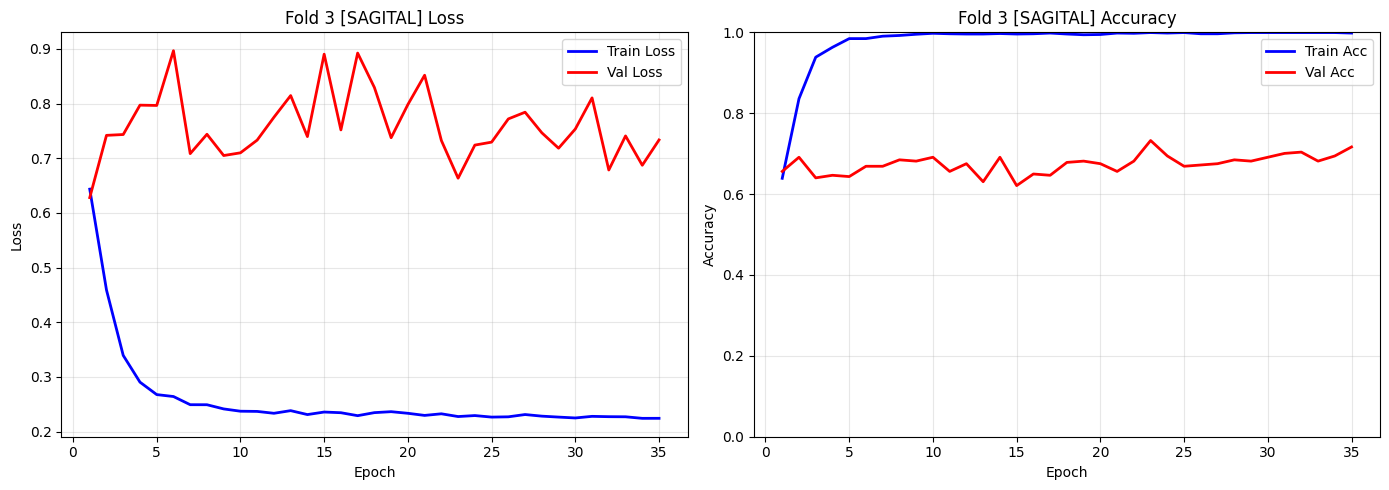


FOLD 3 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7325
  Precision     : 0.7440
  Recall        : 0.7325
  F1 Score      : 0.7332
  Per-Class F1  : CN=0.7407 | EMCI=0.7237 | Fark=0.0171 Normal
  Best Val Loss : 0.6635
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital/sagital_fold_3.pth

FOLD 4 [SAGITAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6737 | Train Acc: 0.6214 | Val Loss: 0.5911 | Val Acc: 0.6920 | Val mF1: 0.6895 | LR_bb: 2.00e-04
         Val tahmin: CN=108, EMCI=181
  Epoch 02 * | Train Loss: 0.4806 | Train Acc: 0.8189 | Val Loss: 0.7103 | Val Acc: 0.7093 | Val mF1: 0.7093 | LR_bb: 2.00e-04


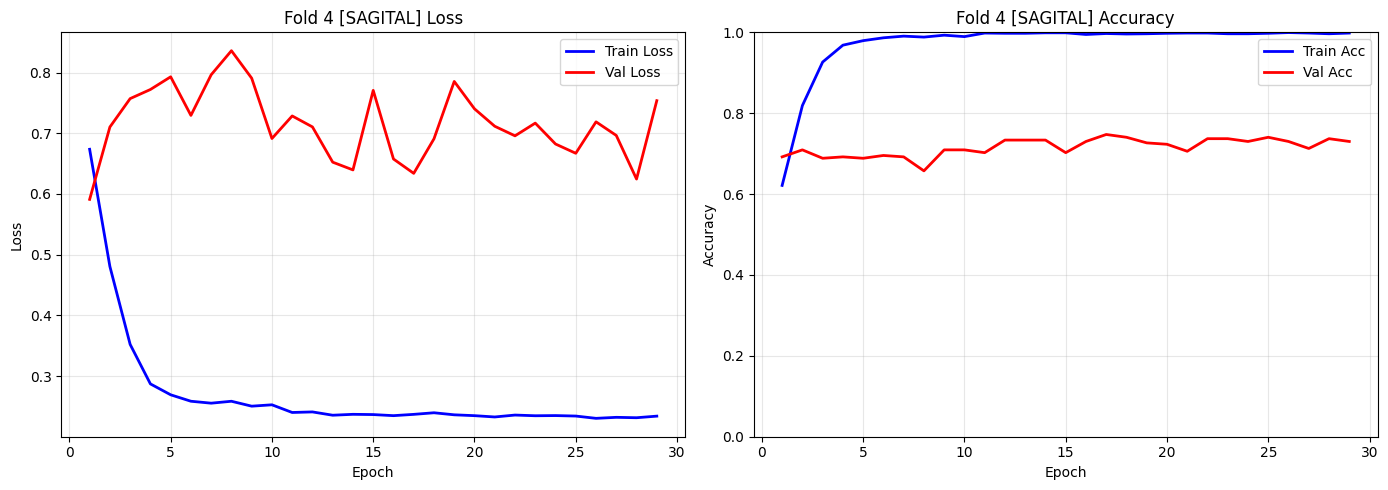


FOLD 4 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7474
  Precision     : 0.7530
  Recall        : 0.7474
  F1 Score      : 0.7476
  Per-Class F1  : CN=0.7509 | EMCI=0.7439 | Fark=0.0070 Normal
  Best Val Loss : 0.6340
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital/sagital_fold_4.pth

FOLD 5 [SAGITAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6383 | Train Acc: 0.6645 | Val Loss: 0.6179 | Val Acc: 0.6812 | Val mF1: 0.6307 | LR_bb: 2.00e-04
         Val tahmin: CN=54, EMCI=222
  Epoch 02   | Train Loss: 0.4571 | Train Acc: 0.8477 | Val Loss: 0.9316 | Val Acc: 0.5978 | Val mF1: 0.5978 | LR_bb: 2.00e-04
 

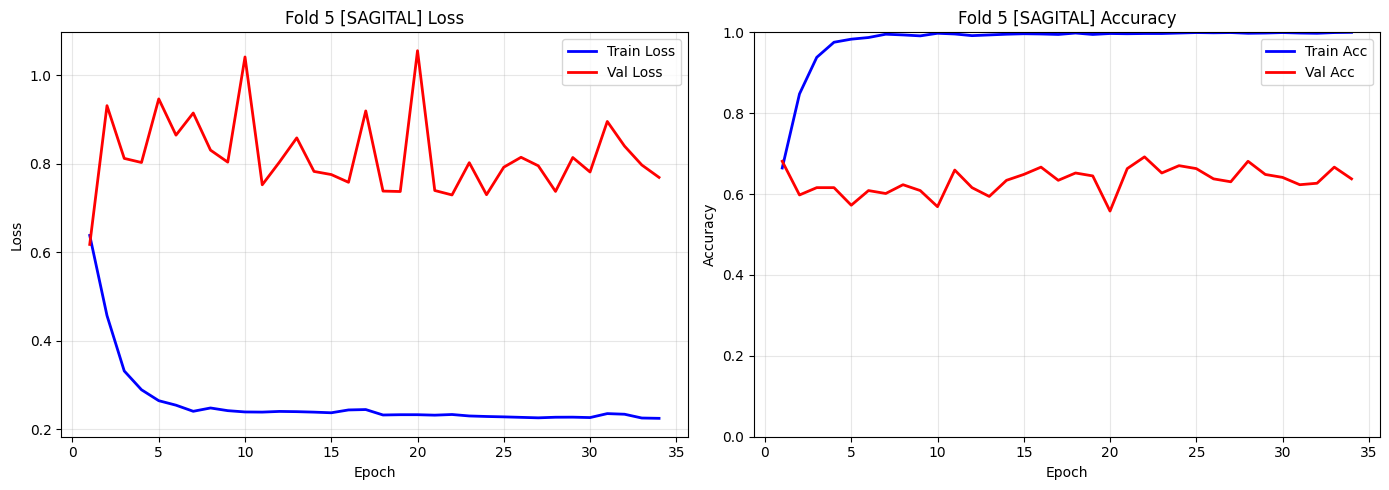


FOLD 5 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6920
  Precision     : 0.6908
  Recall        : 0.6920
  F1 Score      : 0.6912
  Per-Class F1  : CN=0.6383 | EMCI=0.7319 | Fark=0.0936 Normal
  Best Val Loss : 0.7297
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital/sagital_fold_5.pth

SAGITAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.709790 0.707399       0.692001
    2 0.669065 0.670114       0.704634
    3 0.732484 0.733190       0.663487
    4 0.747405 0.747611       0.634026
    5 0.692029 0.691181       0.729750
Ortalama Val Acc: 0.7102 +/- 0.0312
Sure: 43.5 dakika


In [ ]:
import time

sagital_klasoru = os.path.join(ANA_KLASOR, "Sagital")

print(f"EGITIM 1/3: SAGITAL")
print(f"Klasor: {sagital_klasoru}\n")

t0 = time.time()
sonuclar_sagital = duzlem_egit(tum_veriler, 'sagital', CONFIG, sagital_klasoru)
sure_sagital = time.time() - t0

df_sagital = pd.read_csv(os.path.join(sagital_klasoru, 'deney_sonuclari.csv'))
print(f"\nSAGITAL 5-FOLD VALIDATION SONUCLARI:")
print(df_sagital[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_sagital['val_acc'].mean():.4f} +/- {df_sagital['val_acc'].std():.4f}")
print(f"Sure: {sure_sagital/60:.1f} dakika")

EGITIM 2/3: AKSIYAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Aksiyal


DUZLEM: AKSIYAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Aksiyal

FOLD 1 [AKSIYAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6825 | Train Acc: 0.6062 | Val Loss: 0.6271 | Val Acc: 0.6573 | Val mF1: 0.6456 | LR_bb: 2.00e-04
         Val tahmin: CN=94, EMCI=192
  Epoch 02   | Train Loss: 0.4894 | Train Acc: 0.7999 | Val Loss: 0.8082 | Val Acc: 0.5874 | Val mF1: 0.5543 | LR_bb: 2.00e-04
  Epoch 03 * | Train Loss: 0.3283 | Train Acc: 0.9396 | Val Loss: 0.7303 | Val Acc

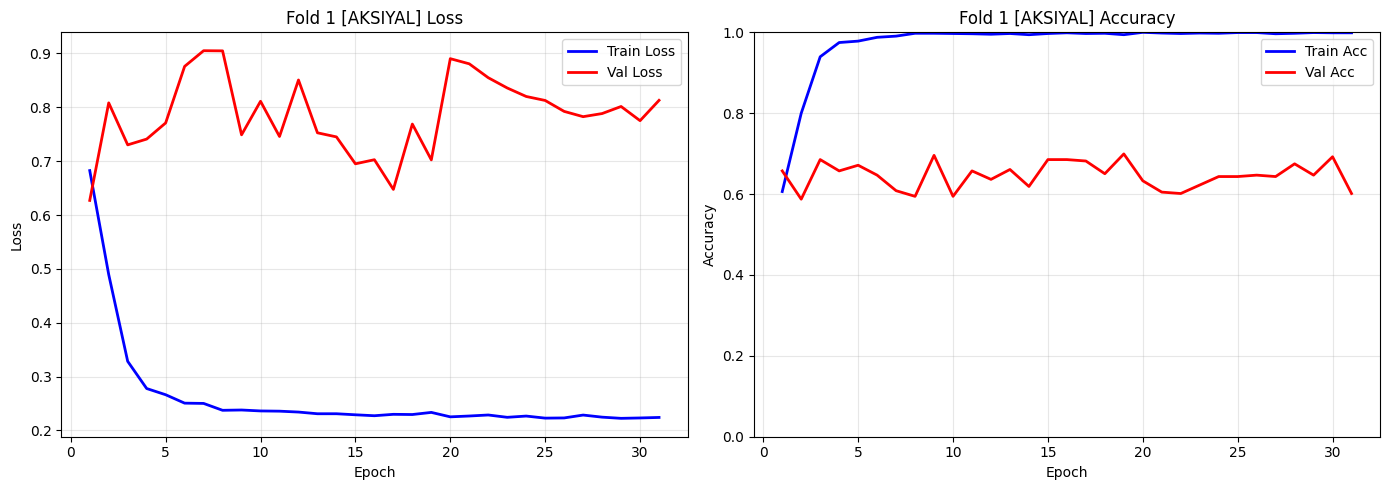


FOLD 1 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6993
  Precision     : 0.6996
  Recall        : 0.6993
  F1 Score      : 0.6993
  Per-Class F1  : CN=0.6972 | EMCI=0.7014 | Fark=0.0042 Normal
  Best Val Loss : 0.7024
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Aksiyal/aksiyal_fold_1.pth

FOLD 2 [AKSIYAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6593 | Train Acc: 0.6192 | Val Loss: 0.6371 | Val Acc: 0.5827 | Val mF1: 0.5824 | LR_bb: 2.00e-04
         Val tahmin: CN=108, EMCI=170
  Epoch 02   | Train Loss: 0.4977 | Train Acc: 0.8037 | Val Loss: 0.8368 | Val Acc: 0.5791 | Val mF1: 0.5791 | LR_bb: 2.00e-04


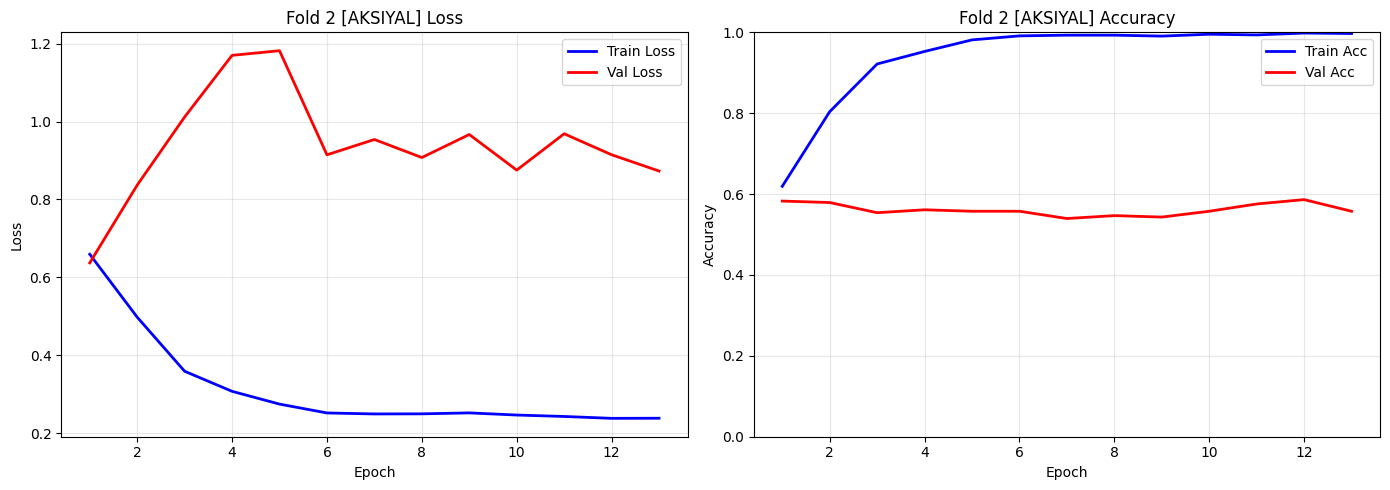


FOLD 2 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.5827
  Precision     : 0.6241
  Recall        : 0.5827
  F1 Score      : 0.5804
  Per-Class F1  : CN=0.5704 | EMCI=0.5944 | Fark=0.0240 Normal
  Best Val Loss : 0.6371
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Aksiyal/aksiyal_fold_2.pth

FOLD 3 [AKSIYAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6660 | Train Acc: 0.6020 | Val Loss: 0.7238 | Val Acc: 0.6306 | Val mF1: 0.6049 | LR_bb: 2.00e-04
         Val tahmin: CN=219, EMCI=95
  Epoch 02 * | Train Loss: 0.5003 | Train Acc: 0.8091 | Val Loss: 0.7731 | Val Acc: 0.6847 | Val mF1: 0.6747 | LR_bb: 2.00e-04
 

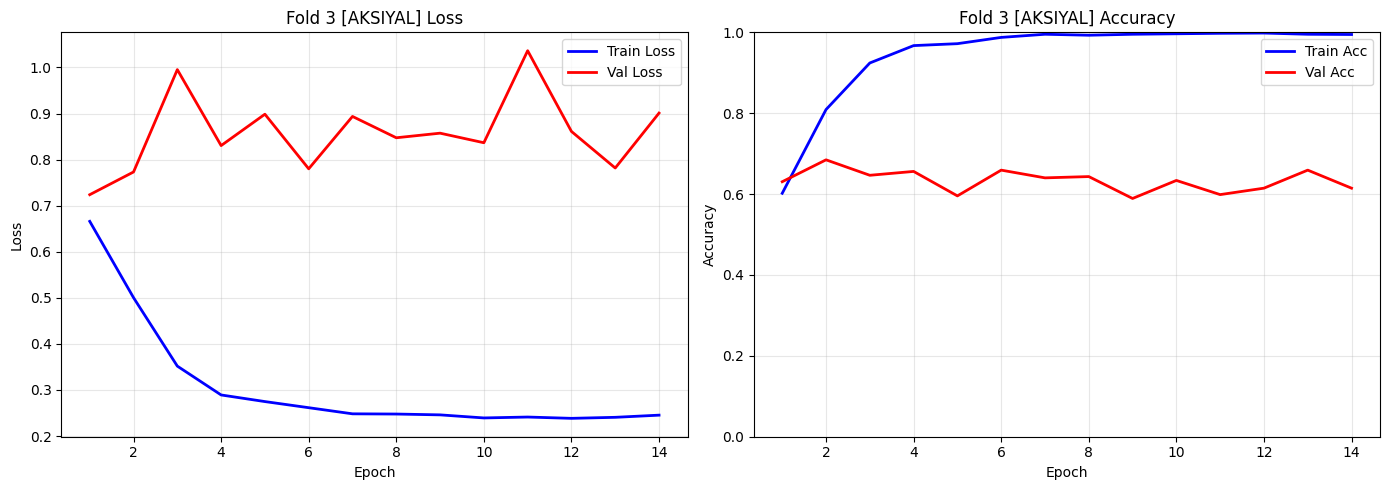


FOLD 3 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6847
  Precision     : 0.6829
  Recall        : 0.6847
  F1 Score      : 0.6813
  Per-Class F1  : CN=0.7317 | EMCI=0.6178 | Fark=0.1139 KONTROL ET
  Best Val Loss : 0.7731
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Aksiyal/aksiyal_fold_3.pth

FOLD 4 [AKSIYAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6780 | Train Acc: 0.6008 | Val Loss: 0.6086 | Val Acc: 0.6747 | Val mF1: 0.6606 | LR_bb: 2.00e-04
         Val tahmin: CN=75, EMCI=214
  Epoch 02 * | Train Loss: 0.5170 | Train Acc: 0.7942 | Val Loss: 0.6342 | Val Acc: 0.6747 | Val mF1: 0.6747 | LR_bb: 2.00e-

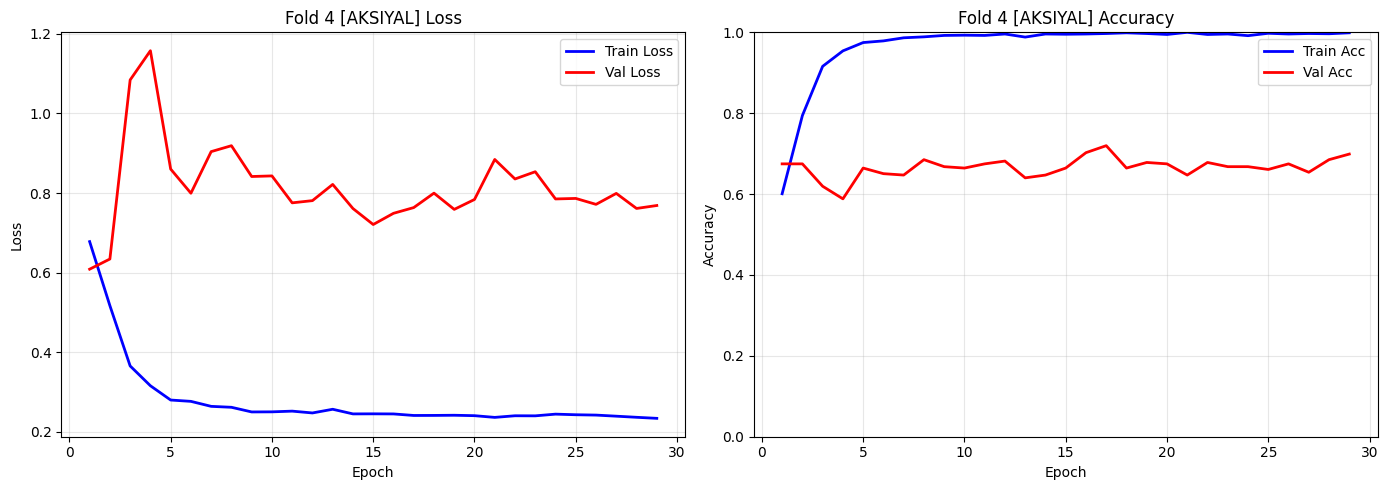


FOLD 4 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.7197
  Precision     : 0.7242
  Recall        : 0.7197
  F1 Score      : 0.7200
  Per-Class F1  : CN=0.7254 | EMCI=0.7138 | Fark=0.0116 Normal
  Best Val Loss : 0.7635
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Aksiyal/aksiyal_fold_4.pth

FOLD 5 [AKSIYAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6593 | Train Acc: 0.6219 | Val Loss: 0.5819 | Val Acc: 0.7101 | Val mF1: 0.6622 | LR_bb: 2.00e-04
         Val tahmin: CN=52, EMCI=224
  Epoch 02   | Train Loss: 0.5062 | Train Acc: 0.8081 | Val Loss: 0.7086 | Val Acc: 0.5870 | Val mF1: 0.5838 | LR_bb: 2.00e-04
 

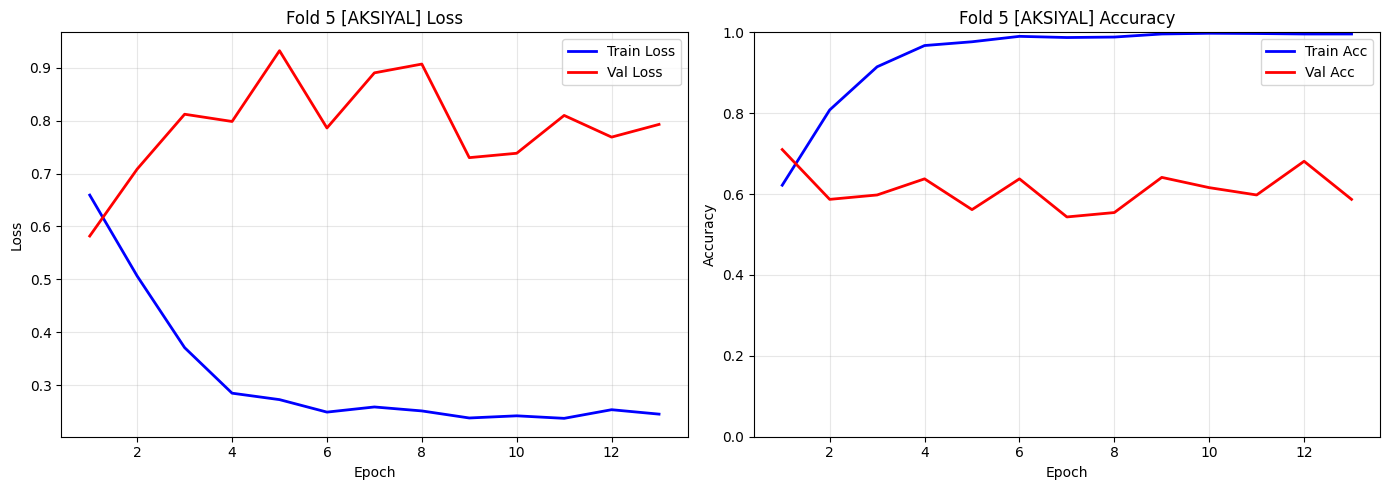


FOLD 5 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.7101
  Precision     : 0.7631
  Recall        : 0.7101
  F1 Score      : 0.6788
  Per-Class F1  : CN=0.5349 | EMCI=0.7895 | Fark=0.2546 KONTROL ET
  Best Val Loss : 0.5819
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Aksiyal/aksiyal_fold_5.pth

AKSIYAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.699301 0.699330       0.702429
    2 0.582734 0.580399       0.637069
    3 0.684713 0.681266       0.773148
    4 0.719723 0.720025       0.763492
    5 0.710145 0.678782       0.581926
Ortalama Val Acc: 0.6793 +/- 0.0555
Sure: 29.3 dakika


In [ ]:
import time

aksiyal_klasoru = os.path.join(ANA_KLASOR, "Aksiyal")

print(f"EGITIM 2/3: AKSIYAL")
print(f"Klasor: {aksiyal_klasoru}\n")

t0 = time.time()
sonuclar_aksiyal = duzlem_egit(tum_veriler, 'aksiyal', CONFIG, aksiyal_klasoru)
sure_aksiyal = time.time() - t0

df_aksiyal = pd.read_csv(os.path.join(aksiyal_klasoru, 'deney_sonuclari.csv'))
print(f"\nAKSIYAL 5-FOLD VALIDATION SONUCLARI:")
print(df_aksiyal[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_aksiyal['val_acc'].mean():.4f} +/- {df_aksiyal['val_acc'].std():.4f}")
print(f"Sure: {sure_aksiyal/60:.1f} dakika")

EGITIM 3/3: KORONAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Koronal


DUZLEM: KORONAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Koronal

FOLD 1 [KORONAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6767 | Train Acc: 0.6180 | Val Loss: 0.6748 | Val Acc: 0.6259 | Val mF1: 0.6234 | LR_bb: 2.00e-04
         Val tahmin: CN=169, EMCI=117
  Epoch 02 * | Train Loss: 0.5124 | Train Acc: 0.8016 | Val Loss: 0.7227 | Val Acc: 0.6678 | Val mF1: 0.6356 | LR_bb: 2.00e-04
  Epoch 03   | Train Loss: 0.3666 | Train Acc: 0.9149 | Val Loss: 0.8388 | Val Ac

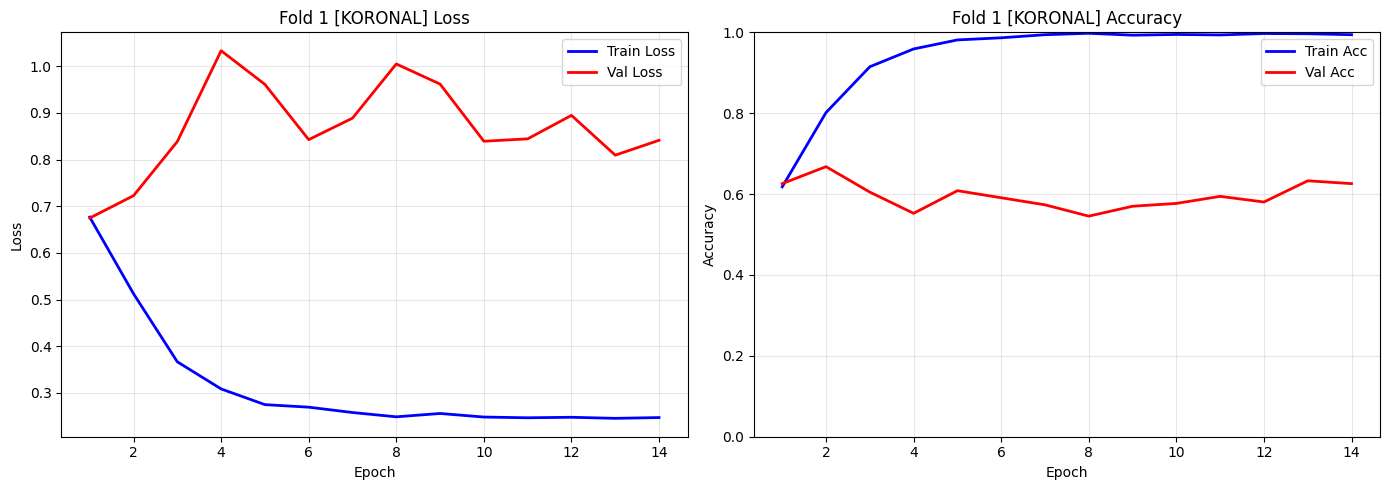


FOLD 1 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6678
  Precision     : 0.7384
  Recall        : 0.6678
  F1 Score      : 0.6379
  Per-Class F1  : CN=0.5274 | EMCI=0.7439 | Fark=0.2166 KONTROL ET
  Best Val Loss : 0.7227
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Koronal/koronal_fold_1.pth

FOLD 2 [KORONAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6586 | Train Acc: 0.6221 | Val Loss: 0.6885 | Val Acc: 0.6007 | Val mF1: 0.5845 | LR_bb: 2.00e-04
         Val tahmin: CN=61, EMCI=217
  Epoch 02 * | Train Loss: 0.4957 | Train Acc: 0.8067 | Val Loss: 0.7190 | Val Acc: 0.6403 | Val mF1: 0.6144 | LR_bb: 2.00e-

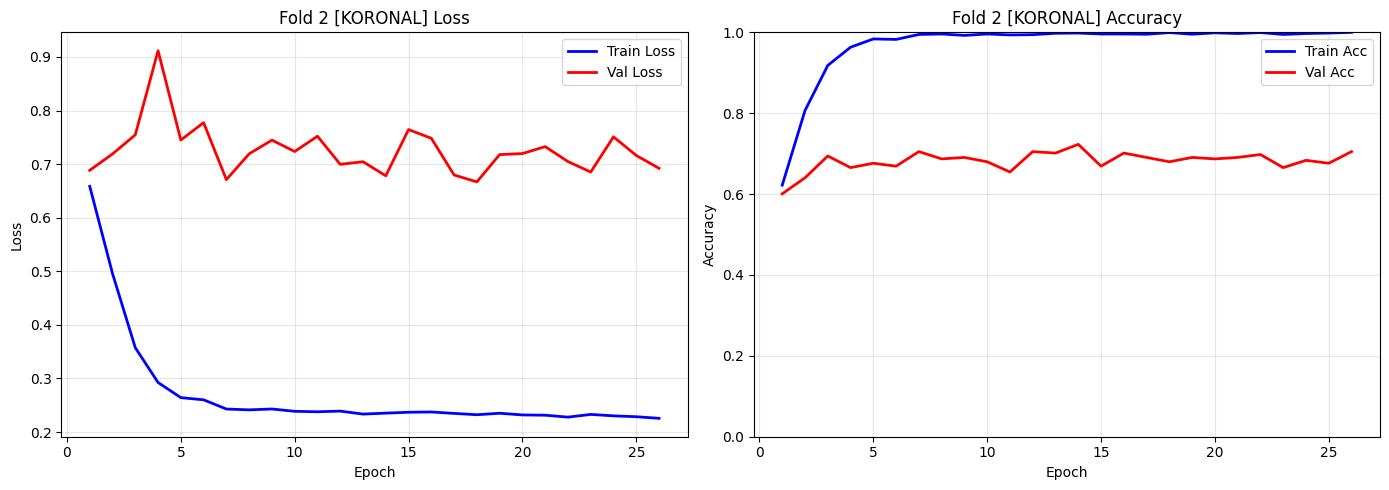


FOLD 2 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.7230
  Precision     : 0.7241
  Recall        : 0.7230
  F1 Score      : 0.7235
  Per-Class F1  : CN=0.7601 | EMCI=0.6723 | Fark=0.0878 Normal
  Best Val Loss : 0.6783
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Koronal/koronal_fold_2.pth

FOLD 3 [KORONAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6712 | Train Acc: 0.6420 | Val Loss: 0.6932 | Val Acc: 0.5924 | Val mF1: 0.5834 | LR_bb: 2.00e-04
         Val tahmin: CN=185, EMCI=129
  Epoch 02 * | Train Loss: 0.4875 | Train Acc: 0.8091 | Val Loss: 0.7150 | Val Acc: 0.7070 | Val mF1: 0.7011 | LR_bb: 2.00e-04


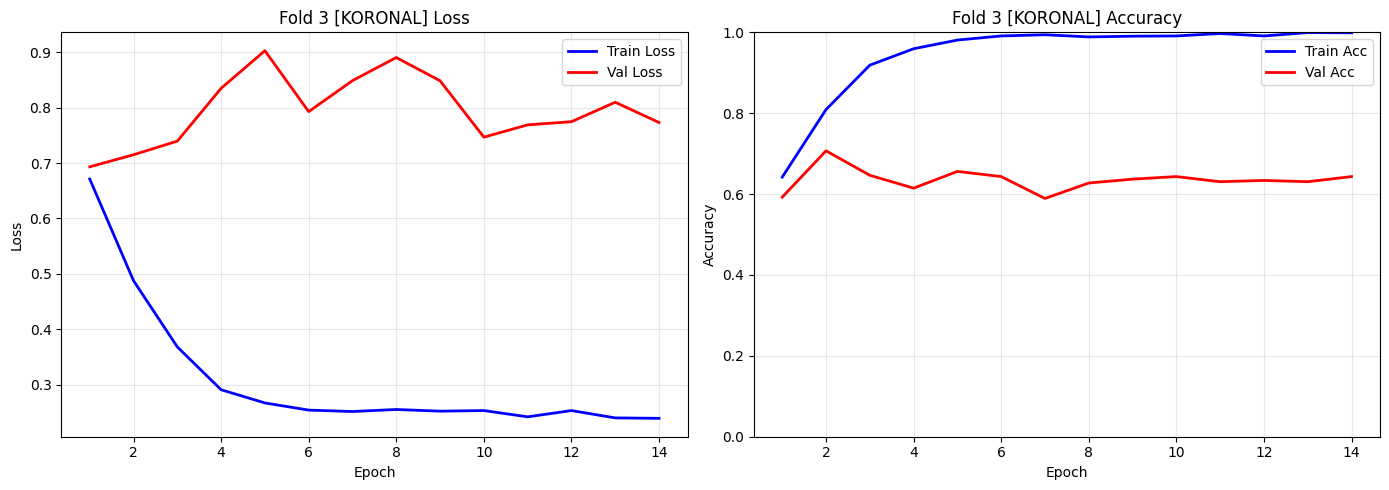


FOLD 3 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.7070
  Precision     : 0.7910
  Recall        : 0.7070
  F1 Score      : 0.6963
  Per-Class F1  : CN=0.6593 | EMCI=0.7430 | Fark=0.0838 Normal
  Best Val Loss : 0.7150
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Koronal/koronal_fold_3.pth

FOLD 4 [KORONAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6685 | Train Acc: 0.6085 | Val Loss: 0.6441 | Val Acc: 0.6540 | Val mF1: 0.6367 | LR_bb: 2.00e-04
         Val tahmin: CN=71, EMCI=218
  Epoch 02 * | Train Loss: 0.4983 | Train Acc: 0.8019 | Val Loss: 0.7135 | Val Acc: 0.6401 | Val mF1: 0.6400 | LR_bb: 2.00e-04
 

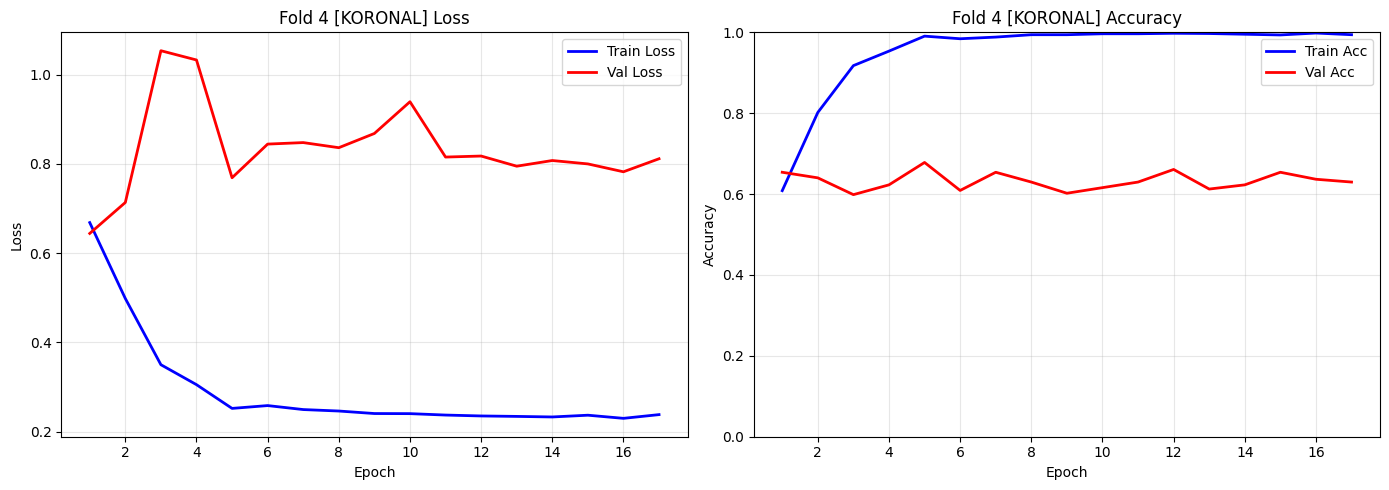


FOLD 4 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6782
  Precision     : 0.6774
  Recall        : 0.6782
  F1 Score      : 0.6768
  Per-Class F1  : CN=0.7103 | EMCI=0.6381 | Fark=0.0721 Normal
  Best Val Loss : 0.7690
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Koronal/koronal_fold_4.pth

FOLD 5 [KORONAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.65
  Epoch 01 * | Train Loss: 0.6678 | Train Acc: 0.6243 | Val Loss: 0.6218 | Val Acc: 0.6775 | Val mF1: 0.6560 | LR_bb: 2.00e-04
         Val tahmin: CN=87, EMCI=189
  Epoch 02 * | Train Loss: 0.5008 | Train Acc: 0.7970 | Val Loss: 0.6882 | Val Acc: 0.7101 | Val mF1: 0.6643 | LR_bb: 2.00e-04
 

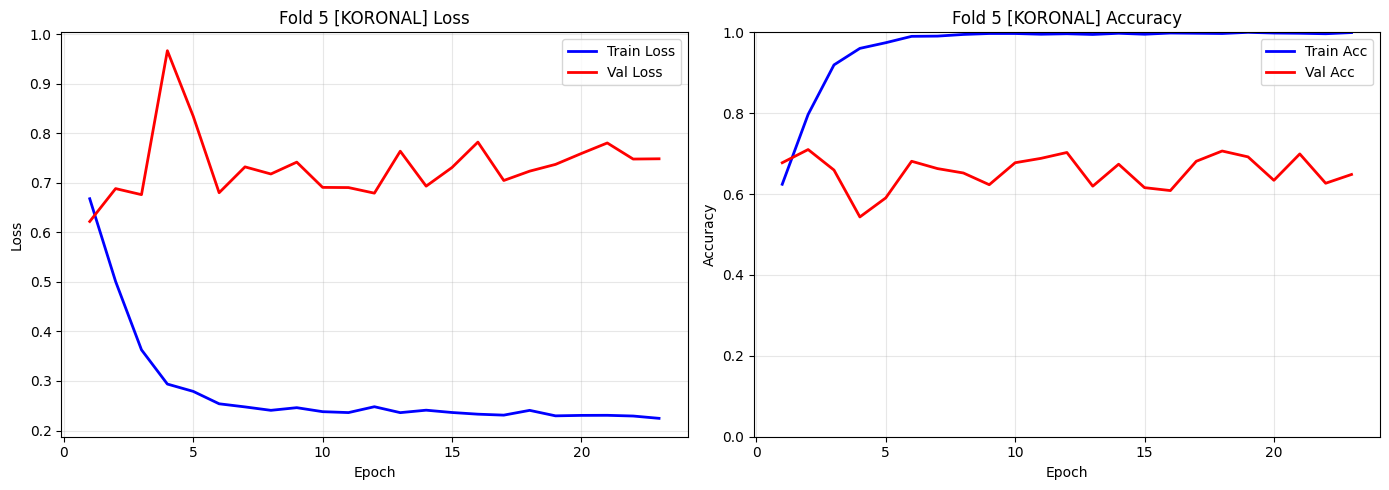


FOLD 5 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6884
  Precision     : 0.6862
  Recall        : 0.6884
  F1 Score      : 0.6860
  Per-Class F1  : CN=0.6228 | EMCI=0.7346 | Fark=0.1118 KONTROL ET
  Best Val Loss : 0.6903
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Koronal/koronal_fold_5.pth

KORONAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.667832 0.637921       0.722733
    2 0.723022 0.723495       0.678280
    3 0.707006 0.696337       0.715019
    4 0.678201 0.676828       0.768966
    5 0.688406 0.685976       0.690293
Ortalama Val Acc: 0.6929 +/- 0.0222
Sure: 27.4 dakika


In [ ]:
import time

koronal_klasoru = os.path.join(ANA_KLASOR, "Koronal")

print(f"EGITIM 3/3: KORONAL")
print(f"Klasor: {koronal_klasoru}\n")

t0 = time.time()
sonuclar_koronal = duzlem_egit(tum_veriler, 'koronal', CONFIG, koronal_klasoru)
sure_koronal = time.time() - t0

df_koronal = pd.read_csv(os.path.join(koronal_klasoru, 'deney_sonuclari.csv'))
print(f"\nKORONAL 5-FOLD VALIDATION SONUCLARI:")
print(df_koronal[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_koronal['val_acc'].mean():.4f} +/- {df_koronal['val_acc'].std():.4f}")
print(f"Sure: {sure_koronal/60:.1f} dakika")

TOPLU VALIDATION SONUCLARI (Per-Plane)

--- SAGITAL ---
 fold  val_acc   val_f1  val_f1_cn  val_f1_emci  best_val_loss
    1 0.709790 0.707399   0.677043     0.736508       0.692001
    2 0.669065 0.670114   0.710692     0.613445       0.704634
    3 0.732484 0.733190   0.740741     0.723684       0.663487
    4 0.747405 0.747611   0.750853     0.743860       0.634026
    5 0.692029 0.691181   0.638298     0.731861       0.729750
  Ortalama Val Acc : 0.7102 +/- 0.0312
  Ortalama Val F1  : 0.7099
  CN F1 / EMCI F1  : 0.7035 / 0.7099

--- AKSIYAL ---
 fold  val_acc   val_f1  val_f1_cn  val_f1_emci  best_val_loss
    1 0.699301 0.699330   0.697183     0.701389       0.702429
    2 0.582734 0.580399   0.570370     0.594406       0.637069
    3 0.684713 0.681266   0.731707     0.617761       0.773148
    4 0.719723 0.720025   0.725424     0.713781       0.763492
    5 0.710145 0.678782   0.534884     0.789474       0.581926
  Ortalama Val Acc : 0.6793 +/- 0.0555
  Ortalama Val F1  : 0.6720


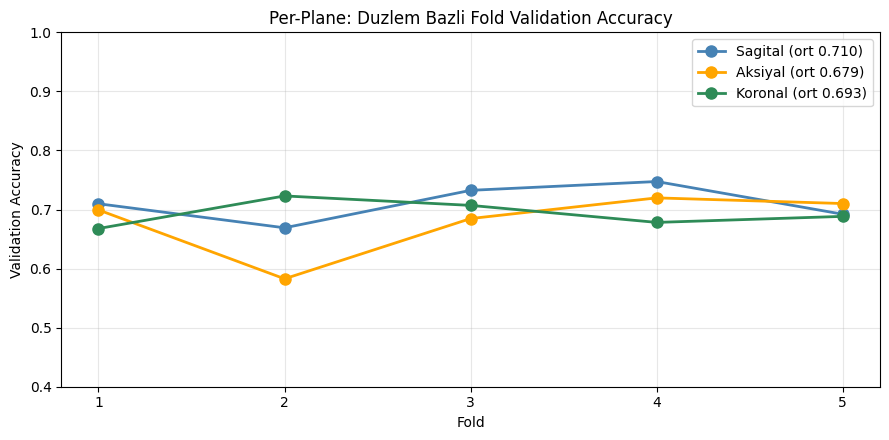

In [ ]:
# ===== TOPLU VALIDATION OZETI (3 duzlem x 5 fold) =====
import pandas as pd, os

# Modeller baska bir oturumda egitildiyse ANA_KLASOR'u elle sabitle:

duzlemler = {
    'Sagital': os.path.join(ANA_KLASOR, 'Sagital', 'deney_sonuclari.csv'),
    'Aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal', 'deney_sonuclari.csv'),
    'Koronal': os.path.join(ANA_KLASOR, 'Koronal', 'deney_sonuclari.csv'),
}

tum_dfler = []
print("="*70)
print("TOPLU VALIDATION SONUCLARI (Per-Plane)")
print("="*70)

for ad, yol in duzlemler.items():
    if not os.path.exists(yol):
        print(f"\n[{ad}] CSV bulunamadi ({yol}) - bu duzlem egitilmemis olabilir.")
        continue
    df = pd.read_csv(yol)
    df['duzlem'] = ad
    tum_dfler.append(df)

    print(f"\n--- {ad.upper()} ---")
    print(df[['fold', 'val_acc', 'val_f1', 'val_f1_cn', 'val_f1_emci', 'best_val_loss']].to_string(index=False))
    print(f"  Ortalama Val Acc : {df['val_acc'].mean():.4f} +/- {df['val_acc'].std():.4f}")
    print(f"  Ortalama Val F1  : {df['val_f1'].mean():.4f}")
    print(f"  CN F1 / EMCI F1  : {df['val_f1_cn'].mean():.4f} / {df['val_f1_emci'].mean():.4f}")

if tum_dfler:
    hepsi = pd.concat(tum_dfler, ignore_index=True)

    print("\n" + "="*70)
    print("DUZLEM BAZLI OZET TABLOSU")
    print("="*70)
    ozet = hepsi.groupby('duzlem').agg(
        val_acc_ort=('val_acc', 'mean'),
        val_acc_std=('val_acc', 'std'),
        val_f1_ort=('val_f1', 'mean'),
        cn_f1=('val_f1_cn', 'mean'),
        emci_f1=('val_f1_emci', 'mean'),
    ).round(4)
    print(ozet.to_string())

    print("\n" + "="*70)
    print("GENEL ORTALAMA (15 model = 3 duzlem x 5 fold)")
    print("="*70)
    print(f"  Val Accuracy : {hepsi['val_acc'].mean():.4f} +/- {hepsi['val_acc'].std():.4f}")
    print(f"  Val F1       : {hepsi['val_f1'].mean():.4f} +/- {hepsi['val_f1'].std():.4f}")
    print(f"  CN F1        : {hepsi['val_f1_cn'].mean():.4f}")
    print(f"  EMCI F1      : {hepsi['val_f1_emci'].mean():.4f}")

    # Gorsel: duzlem bazli fold accuracy
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 4.5))
    renkler = {'Sagital': 'steelblue', 'Aksiyal': 'orange', 'Koronal': 'seagreen'}
    for ad in ['Sagital', 'Aksiyal', 'Koronal']:
        d = hepsi[hepsi['duzlem'] == ad]
        if len(d) == 0: continue
        ax.plot(d['fold'], d['val_acc'], 'o-', label=f"{ad} (ort {d['val_acc'].mean():.3f})",
                color=renkler[ad], lw=2, markersize=8)
    ax.set_xlabel('Fold'); ax.set_ylabel('Validation Accuracy')
    ax.set_title('Per-Plane: Duzlem Bazli Fold Validation Accuracy')
    ax.set_xticks([1,2,3,4,5]); ax.set_ylim([0.4, 1.0])
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(ANA_KLASOR, 'toplu_val_accuracy.png'), dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("\nHic CSV bulunamadi. Once egitimi calistir veya ANA_KLASOR'u dogru klasore sabitle.")

TEST seti: 296 seans  (CN=148, EMCI=148)

[SAGITAL] 5 fold modeli test ediliyor...
  fold 1 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital/sagital_fold_1.pth)
  fold 2 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital/sagital_fold_2.pth)
  fold 3 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital/sagital_fold_3.pth)
  fold 4 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital/sagital_fold_4.pth)
  fold 5 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58/Sagital/sagital_fold_5.pth)

[AKSIYAL] 5 fold modeli test ediliyor...
  fold 1 tamam (/content/drive/MyDrive/GizemZor/YA

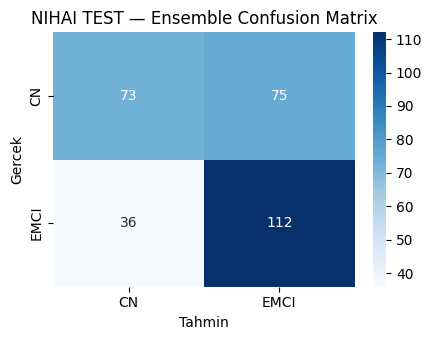

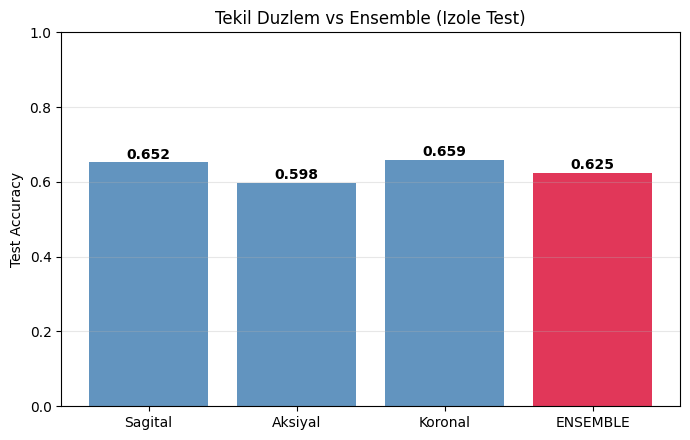


Kaydedildi: final_test_tahminler.csv, final_test_ozet.csv
Bitti.


In [ ]:
# ============================================================
# NIHAI TEST: izole test seti + 15 model agirlikli ensemble
# ============================================================
import numpy as np
ANA_KLASOR = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58'


# --- 1) Izole test verisini oku (train ile AYNI yapida) ---
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]

test_veriler = veri_listesi_olustur(test_config)
n_cn_te   = sum(1 for x in test_veriler if x['etiket'] == 0)
n_emci_te = sum(1 for x in test_veriler if x['etiket'] == 1)
print(f"TEST seti: {len(test_veriler)} seans  (CN={n_cn_te}, EMCI={n_emci_te})")
assert len(test_veriler) > 0, "Test seti bos! kaynak_CN_test / kaynak_EMCI_test yollarini kontrol et."

# Gercek etiket sozlugu: sid -> etiket
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# --- 2) Ensemble agirliklari (degistirilebilir) ---
DUZLEM_AGIRLIK = {'sagital': 1.0, 'aksiyal': 1.0, 'koronal': 1.0}

DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# --- 3) Tahmin yardimci fonksiyonu (seans_id ile birlikte) ---
def tahmin_al(model, loader):
    model.eval()
    sids_all, probs_all = [], []
    with torch.no_grad():
        for sids, slices, lbls in loader:
            slices = slices.to(DEVICE)
            logits = model(slices)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            sids_all.extend(list(sids))
            probs_all.extend(probs.tolist())
    return sids_all, probs_all

# --- 4) Her duzlem icin 5 fold modelin olasiligini ortala ---
# plane_avg[duzlem][sid] = ortalama [prob_cn, prob_emci]
plane_avg = {}

for duzlem, klasor in DUZLEM_KLASOR.items():
    print(f"\n[{duzlem.upper()}] 5 fold modeli test ediliyor...")
    test_loader = loader_olustur(test_veriler, duzlem, CONFIG, shuffle=False)

    toplam = {}   # sid -> np.array([p_cn, p_emci]) toplam
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{duzlem}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        for sid, pr in zip(sids, probs):
            toplam.setdefault(sid, np.zeros(2))
            toplam[sid] += np.array(pr)
        print(f"  fold {fold} tamam ({m_path})")
        del model
        torch.cuda.empty_cache()

    plane_avg[duzlem] = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# --- 5) Agirlikli ensemble (3 duzlem) ---
toplam_agirlik = sum(DUZLEM_AGIRLIK.values())
ortak_sid = set.intersection(*[set(plane_avg[d].keys()) for d in DUZLEM_KLASOR])
print(f"\nUc duzlemde de tahmin edilen ortak seans: {len(ortak_sid)}")

y_true, y_pred = [], []
y_pred_duzlem = {d: [] for d in DUZLEM_KLASOR}
kayit = []

for sid in sorted(ortak_sid):
    fused = np.zeros(2)
    for d in DUZLEM_KLASOR:
        fused += DUZLEM_AGIRLIK[d] * plane_avg[d][sid]
    fused /= toplam_agirlik

    pred = int(np.argmax(fused))
    true = sid_true[sid]
    y_true.append(true)
    y_pred.append(pred)

    satir = {'seans_id': sid,
             'gercek': 'CN' if true == 0 else 'EMCI',
             'ens_prob_cn': fused[0], 'ens_prob_emci': fused[1],
             'ensemble': 'CN' if pred == 0 else 'EMCI'}
    for d in DUZLEM_KLASOR:
        dp = int(np.argmax(plane_avg[d][sid]))
        y_pred_duzlem[d].append(dp)
        satir[d] = 'CN' if dp == 0 else 'EMCI'
    satir['dogru_mu'] = (true == pred)
    kayit.append(satir)

# --- 6) Metrikler ---
acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=[0, 1], zero_division=0
)

print(f"\n{'='*70}")
print("NIHAI TEST SONUCLARI (Agirlikli Ensemble)")
print(f"{'='*70}")
print(f"Agirliklar    : {DUZLEM_AGIRLIK}")
print(f"Test seans    : {len(y_true)}")
print(f"\nTekil duzlem test accuracy:")
for d in DUZLEM_KLASOR:
    print(f"  {d.capitalize():9s}: {accuracy_score(y_true, y_pred_duzlem[d]):.4f}")
print(f"\n  ENSEMBLE Accuracy : {acc:.4f}")
print(f"  Precision         : {p:.4f}")
print(f"  Recall            : {r:.4f}")
print(f"  F1 Score          : {f:.4f}")
print(f"  Per-Class F1      : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")

print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

# --- 7) Confusion matrix ---
plt.figure(figsize=(4.5, 3.5))
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CN', 'EMCI'], yticklabels=['CN', 'EMCI'])
plt.title("NIHAI TEST — Ensemble Confusion Matrix")
plt.xlabel("Tahmin"); plt.ylabel("Gercek")
plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'final_test_confusion_matrix.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# --- 8) Tekil duzlem vs ensemble grafigi ---
fig, axg = plt.subplots(figsize=(7, 4.5))
isimler = [d.capitalize() for d in DUZLEM_KLASOR] + ['ENSEMBLE']
degerler = [accuracy_score(y_true, y_pred_duzlem[d]) for d in DUZLEM_KLASOR] + [acc]
renkler = ['steelblue']*3 + ['crimson']
axg.bar(isimler, degerler, color=renkler, alpha=0.85)
for i, v in enumerate(degerler):
    axg.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
axg.set_ylabel('Test Accuracy'); axg.set_ylim([0, 1])
axg.set_title('Tekil Duzlem vs Ensemble (Izole Test)')
axg.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'final_test_karsilastirma.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# --- 9) Kayit ---
df_kayit = pd.DataFrame(kayit)
df_kayit.to_csv(os.path.join(ANA_KLASOR, 'final_test_tahminler.csv'), index=False)
pd.DataFrame([{
    'agirlik_sag': DUZLEM_AGIRLIK['sagital'],
    'agirlik_ax' : DUZLEM_AGIRLIK['aksiyal'],
    'agirlik_kor': DUZLEM_AGIRLIK['koronal'],
    'test_acc': acc, 'precision': p, 'recall': r, 'f1': f,
    'f1_cn': f_pc[0], 'f1_emci': f_pc[1], 'n_test': len(y_true)
}]).to_csv(os.path.join(ANA_KLASOR, 'final_test_ozet.csv'), index=False)

print(f"\nKaydedildi: final_test_tahminler.csv, final_test_ozet.csv")
print("Bitti.")

In [ ]:
# --- sonuclari sakla (grafik icin) ---
try: SONUCLAR
except NameError: SONUCLAR = {'duzlem': {}, 'strateji': {}}
for d in DUZLEM_KLASOR:
    SONUCLAR['duzlem'][d.capitalize()] = accuracy_score(y_true, y_pred_duzlem[d])
SONUCLAR['strateji']['3-duzlem\nesit ensemble'] = acc

  Sagital   val_acc ort: 0.7102
  Aksiyal   val_acc ort: 0.6793
  Koronal   val_acc ort: 0.6929

VALIDATION'da en iyi duzlem: SAGITAL  (0.7102)

EN IYI DUZLEM (SAGITAL) 5-FOLD ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6520
   Precision    : 0.6546 | Recall: 0.6520 | F1: 0.6506
   Per-Class F1 : CN=0.6282 | EMCI=0.6730

              precision    recall  f1-score   support

          CN       0.67      0.59      0.63       148
        EMCI       0.63      0.72      0.67       148

    accuracy                           0.65       296
   macro avg       0.65      0.65      0.65       296
weighted avg       0.65      0.65      0.65       296



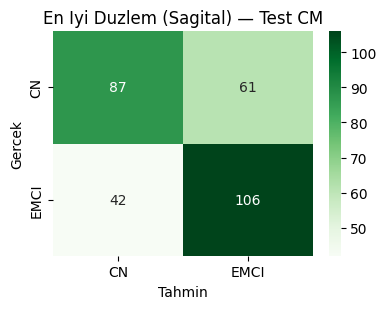

In [ ]:
# ===== EK HUCRE A: VALIDATION'da en iyi DUZLEMI sec, 5-fold ensemble test =====
import numpy as np, os

# Modeller baska oturumda egitildiyse dogru klasoru sabitle:
ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58'

DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Her duzlemin VALIDATION ortalamasini oku, en iyisini sec (TEST'e gore DEGIL)
val_ort = {}
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    val_ort[d] = dfv['val_acc'].mean()
    print(f"  {d.capitalize():9s} val_acc ort: {val_ort[d]:.4f}")
en_iyi_duzlem = max(val_ort, key=val_ort.get)
print(f"\nVALIDATION'da en iyi duzlem: {en_iyi_duzlem.upper()}  ({val_ort[en_iyi_duzlem]:.4f})\n")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) Sadece o duzlemin 5 fold modelini ortala
klasor = DUZLEM_KLASOR[en_iyi_duzlem]
test_loader = loader_olustur(test_veriler, en_iyi_duzlem, CONFIG, shuffle=False)
toplam = {}
for fold in range(1, CONFIG['k_fold'] + 1):
    m_path = os.path.join(klasor, f'{en_iyi_duzlem}_fold_{fold}.pth')
    model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
    model.load_state_dict(torch.load(m_path, weights_only=True))
    sids, probs = tahmin_al(model, test_loader)
    for sid, pr in zip(sids, probs):
        toplam.setdefault(sid, np.zeros(2)); toplam[sid] += np.array(pr)
    del model; torch.cuda.empty_cache()
avg = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# 4) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(avg.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(avg[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"{'='*60}\nEN IYI DUZLEM ({en_iyi_duzlem.upper()}) 5-FOLD ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Greens',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title(f"En Iyi Duzlem ({en_iyi_duzlem.capitalize()}) — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()

In [ ]:
try: SONUCLAR
except NameError: SONUCLAR = {'duzlem': {}, 'strateji': {}}
SONUCLAR['strateji']['Val-agirlikli\nensemble'] = acc

Duzlem agirliklari (validation'dan):
   Sagital  : 0.361
   Aksiyal  : 0.308
   Koronal  : 0.331

VAL-AGIRLIKLI DUZLEM ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6216
   Precision    : 0.6302 | Recall: 0.6216 | F1: 0.6153
   Per-Class F1 : CN=0.5659 | EMCI=0.6647

              precision    recall  f1-score   support

          CN       0.66      0.49      0.57       148
        EMCI       0.60      0.75      0.66       148

    accuracy                           0.62       296
   macro avg       0.63      0.62      0.62       296
weighted avg       0.63      0.62      0.62       296



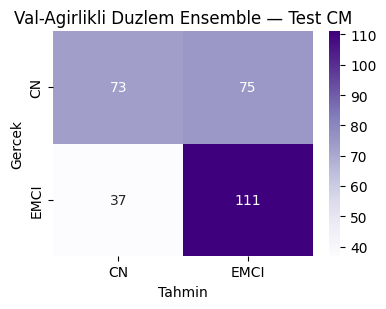

15 model agirligi (validation'dan, normalize):
   Aksiyal   fold 1: 0.068
   Aksiyal   fold 2: 0.028
   Aksiyal   fold 3: 0.063
   Aksiyal   fold 4: 0.075
   Aksiyal   fold 5: 0.072
   Koronal   fold 1: 0.058
   Koronal   fold 2: 0.077
   Koronal   fold 3: 0.071
   Koronal   fold 4: 0.061
   Koronal   fold 5: 0.065
   Sagital   fold 1: 0.072
   Sagital   fold 2: 0.058
   Sagital   fold 3: 0.080
   Sagital   fold 4: 0.085
   Sagital   fold 5: 0.066

15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6284
   Precision    : 0.6365 | Recall: 0.6284 | F1: 0.6228
   Per-Class F1 : CN=0.5769 | EMCI=0.6687

              precision    recall  f1-score   support

          CN       0.67      0.51      0.58       148
        EMCI       0.60      0.75      0.67       148

    accuracy                           0.63       296
   macro avg       0.64      0.63      0.62       296
weighted avg       0.64      0.63      0.62       296



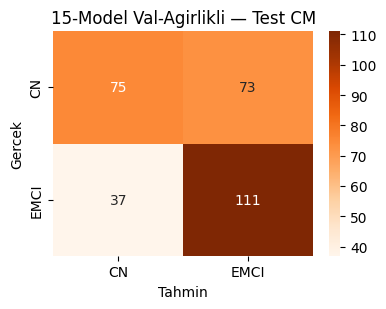

In [ ]:
# ===== EK HUCRE B: VALIDATION accuracy ile DUZLEM-AGIRLIKLI ensemble =====
import numpy as np, os

ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58'


DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Agirliklar VALIDATION'dan: (val_acc - 0.5) ile zayif duzlem otomatik kisilir
agirlik = {}
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    agirlik[d] = max(dfv['val_acc'].mean() - 0.5, 0.0)
toplam_ag = sum(agirlik.values())
agirlik = {d: v / toplam_ag for d, v in agirlik.items()}
print("Duzlem agirliklari (validation'dan):")
for d, w in agirlik.items():
    print(f"   {d.capitalize():9s}: {w:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) Her duzlemin 5-fold ortalamasini al
plane_avg = {}
for d, klasor in DUZLEM_KLASOR.items():
    test_loader = loader_olustur(test_veriler, d, CONFIG, shuffle=False)
    toplam = {}
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{d}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        for sid, pr in zip(sids, probs):
            toplam.setdefault(sid, np.zeros(2)); toplam[sid] += np.array(pr)
        del model; torch.cuda.empty_cache()
    plane_avg[d] = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# 4) Agirlikli birlesim
ortak = set.intersection(*[set(plane_avg[d].keys()) for d in DUZLEM_KLASOR])
y_true, y_pred = [], []
for sid in sorted(ortak):
    fused = np.zeros(2)
    for d in DUZLEM_KLASOR:
        fused += agirlik[d] * plane_avg[d][sid]
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(fused)))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\nVAL-AGIRLIKLI DUZLEM ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Purples',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("Val-Agirlikli Duzlem Ensemble — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()# ===== EK HUCRE C: 15 MODEL — her (duzlem,fold) modeline KENDI val_acc agirligi =====
import numpy as np, os

ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_05_15_58'


DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Her (duzlem,fold) icin VALIDATION agirligi (val_acc - 0.5)
model_agirlik = {}   # (duzlem, fold) -> agirlik
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    for _, row in dfv.iterrows():
        model_agirlik[(d, int(row['fold']))] = max(row['val_acc'] - 0.5, 0.0)
toplam_ag = sum(model_agirlik.values())
print("15 model agirligi (validation'dan, normalize):")
for (d, fold), w in sorted(model_agirlik.items()):
    print(f"   {d.capitalize():9s} fold {fold}: {w/toplam_ag:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) 15 modeli tek tek, kendi agirligiyla topla
toplam_olasilik = {}
for d, klasor in DUZLEM_KLASOR.items():
    test_loader = loader_olustur(test_veriler, d, CONFIG, shuffle=False)
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{d}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        w = model_agirlik[(d, fold)] / toplam_ag
        for sid, pr in zip(sids, probs):
            toplam_olasilik.setdefault(sid, np.zeros(2))
            toplam_olasilik[sid] += w * np.array(pr)
        del model; torch.cuda.empty_cache()

# 4) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(toplam_olasilik.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(toplam_olasilik[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\n15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("15-Model Val-Agirlikli — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()

In [ ]:
try: SONUCLAR
except NameError: SONUCLAR = {'duzlem': {}, 'strateji': {}}
SONUCLAR['strateji']['15-model\nagirlikli'] = acc

15 model agirligi (validation'dan, normalize):
   Aksiyal   fold 1: 0.070
   Aksiyal   fold 2: 0.038
   Aksiyal   fold 3: 0.060
   Aksiyal   fold 4: 0.081
   Aksiyal   fold 5: 0.067
   Koronal   fold 1: 0.052
   Koronal   fold 2: 0.082
   Koronal   fold 3: 0.065
   Koronal   fold 4: 0.060
   Koronal   fold 5: 0.053
   Sagital   fold 1: 0.079
   Sagital   fold 2: 0.066
   Sagital   fold 3: 0.072
   Sagital   fold 4: 0.091
   Sagital   fold 5: 0.065

15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6216
   Precision    : 0.6373 | Recall: 0.6216 | F1: 0.6105
   Per-Class F1 : CN=0.5447 | EMCI=0.6763

              precision    recall  f1-score   support

          CN       0.68      0.45      0.54       148
        EMCI       0.59      0.79      0.68       148

    accuracy                           0.62       296
   macro avg       0.64      0.62      0.61       296
weighted avg       0.64      0.62      0.61       296



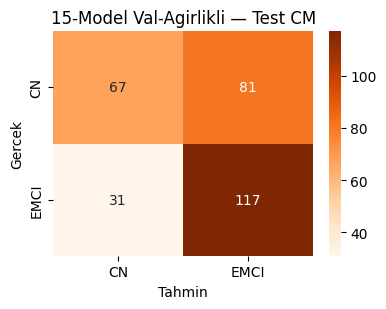

In [ ]:
# ===== EK HUCRE C: 15 MODEL — her (duzlem,fold) modeline KENDI val_acc agirligi =====
import numpy as np, os

ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_04_21_36'


DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Her (duzlem,fold) icin VALIDATION agirligi (val_acc - 0.5)
model_agirlik = {}   # (duzlem, fold) -> agirlik
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    for _, row in dfv.iterrows():
        model_agirlik[(d, int(row['fold']))] = max(row['val_acc'] - 0.5, 0.0)
toplam_ag = sum(model_agirlik.values())
print("15 model agirligi (validation'dan, normalize):")
for (d, fold), w in sorted(model_agirlik.items()):
    print(f"   {d.capitalize():9s} fold {fold}: {w/toplam_ag:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) 15 modeli tek tek, kendi agirligiyla topla
toplam_olasilik = {}
for d, klasor in DUZLEM_KLASOR.items():
    test_loader = loader_olustur(test_veriler, d, CONFIG, shuffle=False)
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{d}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        w = model_agirlik[(d, fold)] / toplam_ag
        for sid, pr in zip(sids, probs):
            toplam_olasilik.setdefault(sid, np.zeros(2))
            toplam_olasilik[sid] += w * np.array(pr)
        del model; torch.cuda.empty_cache()

# 4) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(toplam_olasilik.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(toplam_olasilik[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\n15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("15-Model Val-Agirlikli — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()

In [ ]:
try: SONUCLAR
except NameError: SONUCLAR = {'duzlem': {}, 'strateji': {}}
SONUCLAR['strateji']['15-model\nagirlikli'] = acc

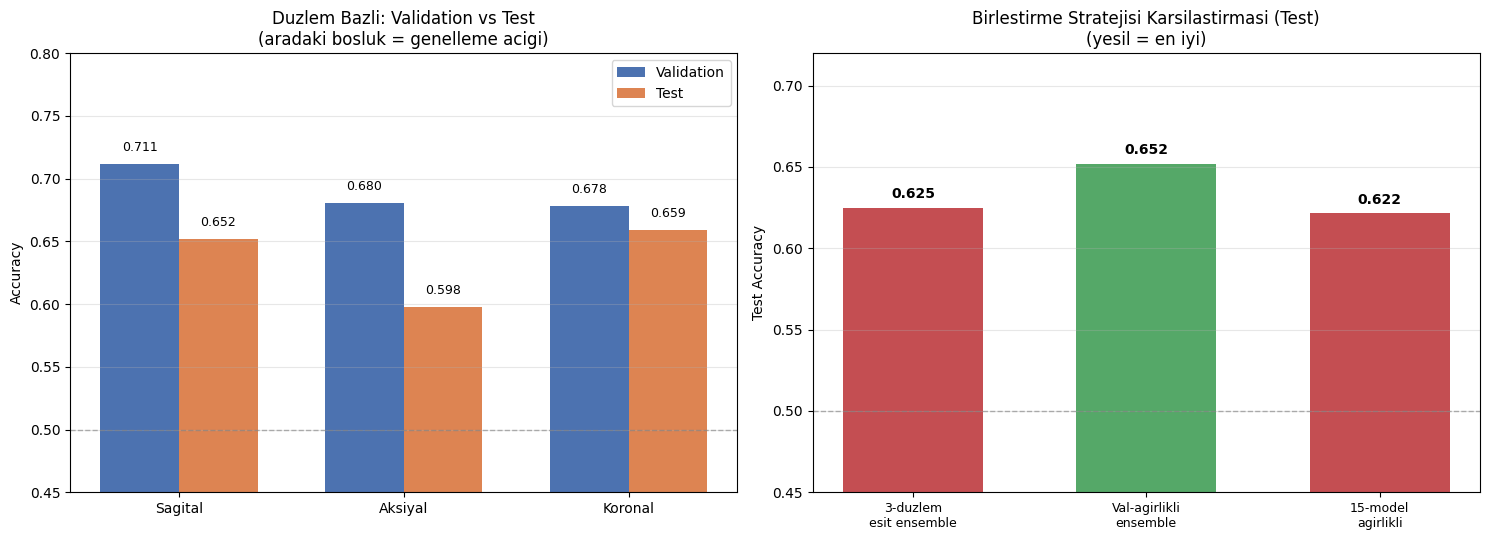

Kaydedildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_04_21_36/val_test_karsilastirma.png


In [ ]:
# ===== GRAFIK: Val vs Test + Strateji Karsilastirmasi (otomatik) =====
import matplotlib.pyplot as plt
import numpy as np, pandas as pd, os

# Validation accuracy'leri CSV'den otomatik oku
duzlem_klasor = {
    'Sagital': os.path.join(ANA_KLASOR, 'Sagital', 'deney_sonuclari.csv'),
    'Aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal', 'deney_sonuclari.csv'),
    'Koronal': os.path.join(ANA_KLASOR, 'Koronal', 'deney_sonuclari.csv'),
}
val_acc = {}
for ad, yol in duzlem_klasor.items():
    try: val_acc[ad] = pd.read_csv(yol)['val_acc'].mean()
    except Exception: val_acc[ad] = np.nan

# Test sonuclari SONUCLAR sozlugunden (test hucrelerinde otomatik dolduruldu)
test_acc_duzlem = SONUCLAR['duzlem']
strateji_test   = SONUCLAR['strateji']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel 1: Duzlem bazli Val vs Test
duzlemler = [d for d in ['Sagital','Aksiyal','Koronal'] if d in test_acc_duzlem]
x = np.arange(len(duzlemler)); w = 0.35
vd = [val_acc.get(d, np.nan) for d in duzlemler]
td = [test_acc_duzlem[d] for d in duzlemler]
b1 = ax1.bar(x - w/2, vd, w, label='Validation', color='#4C72B0')
b2 = ax1.bar(x + w/2, td, w, label='Test', color='#DD8452')
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax1.text(bar.get_x()+bar.get_width()/2, h+0.008, f'{h:.3f}',
                     ha='center', va='bottom', fontsize=9)
ax1.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
ax1.set_xticks(x); ax1.set_xticklabels(duzlemler)
ax1.set_ylabel('Accuracy'); ax1.set_ylim([0.45, 0.80])
ax1.set_title('Duzlem Bazli: Validation vs Test\n(aradaki bosluk = genelleme acigi)')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# Panel 2: Strateji bazli Test
stratejiler = list(strateji_test.keys())
ts = [strateji_test[s] for s in stratejiler]
renkler = ['#55A868' if v == max(ts) else '#C44E52' for v in ts]
bars = ax2.bar(stratejiler, ts, color=renkler, width=0.6)
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h+0.004, f'{h:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
ax2.set_ylabel('Test Accuracy'); ax2.set_ylim([0.45, 0.72])
ax2.set_title('Birlestirme Stratejisi Karsilastirmasi (Test)\n(yesil = en iyi)')
ax2.grid(axis='y', alpha=0.3); plt.setp(ax2.get_xticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'val_test_karsilastirma.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Kaydedildi:", os.path.join(ANA_KLASOR, 'val_test_karsilastirma.png'))